# Max T-statistic per LV in GTEx

In [22]:
library(here)
library(dplyr)
library(ggplot2)
library(ggrepel)
library(tidyr)
library(purrr)
library(yaml)


In [36]:
cfg <- yaml::read_yaml(here("config.yaml"))

MODEL_COLORS <- cfg$MODEL_COLORS
RNASEQ_FRACTION_COLORS <- cfg$RNASEQ_FRACTION_COLORS

MODEL_COLORS[["CLAMP_BP"]]
RNASEQ_FRACTION_COLORS[["100%"]]

[1] "#0077BB"

[1] "#332288"

In [25]:
full_obj <- readRDS(here("output/gtex/gtex_GO_Biological_Process_2025_CLAMP.rds"))
base_obj <- readRDS(here("output/gtex/CLAMPbase.rds"))

In [26]:
B_full <- full_obj$B
B_base <- base_obj$B

In [27]:
gtex_meta <- read.table(
  here("data/gtex/GTEx_Analysis_v8_Annotations_SampleAttributesDS.txt"),
  sep = "\t", header = TRUE, quote = "", fill = TRUE, comment.char = ""
)

common_samples <- Reduce(intersect, list(colnames(B_full), colnames(B_base), gtex_meta$SAMPID))

B_full <- B_full[, common_samples, drop = FALSE]
B_base <- B_base[, common_samples, drop = FALSE]
meta2  <- gtex_meta[match(common_samples, gtex_meta$SAMPID), , drop = FALSE]

In [28]:
head(common_samples)

[1] "GTEX-1117F-0226-SM-5GZZ7" "GTEX-1117F-0426-SM-5EGHI"
[3] "GTEX-1117F-0526-SM-5EGHJ" "GTEX-1117F-0626-SM-5N9CS"
[5] "GTEX-1117F-0726-SM-5GIEN" "GTEX-1117F-1326-SM-5EGHH"

In [29]:
# LV with max |t| per SMTS tissue
max_t_by_SMTS <- function(B_mat, meta_df) {
  tissues <- unique(meta_df$SMTS)
  map_dfr(tissues, function(tiss) {
    g <- meta_df$SMTS == tiss
    t_stats <- apply(B_mat, 1, function(v) {
      x1 <- v[g]; x2 <- v[!g]
      tryCatch(t.test(x1, x2)$statistic[[1]], error = function(e) NA_real_)
    })
    i <- which.max(abs(t_stats))
    tibble(
      SMTS  = tiss,
      LV    = rownames(B_mat)[i],
      t     = unname(t_stats[i]),
      abs_t = abs(t_stats[i])
    )
  })
}

res_base <- max_t_by_SMTS(B_base, meta2) %>%
  rename(LV_base = LV, t_base = t, abs_t_base = abs_t)
res_full <- max_t_by_SMTS(B_full, meta2) %>%
  rename(LV_full = LV, t_full = t, abs_t_full = abs_t)

res_join <- inner_join(res_base, res_full, by = "SMTS")

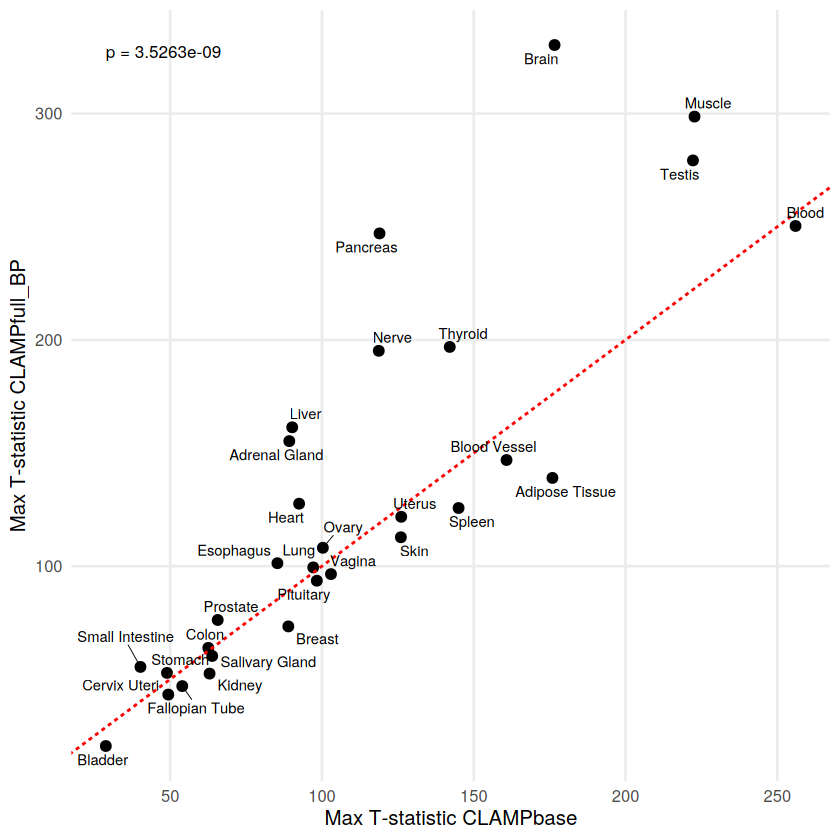

In [30]:
# Correlation Pearson 
ct <- cor.test(res_join$abs_t_base, res_join$abs_t_full, method = "pearson")
p_txt1 <- sprintf("p = %.5g", ct$p.value)
min_x  <- min(res_join$abs_t_base, na.rm = TRUE)
max_y  <- max(res_join$abs_t_full, na.rm = TRUE)

ggplot(res_join, aes(x = abs_t_base, y = abs_t_full)) +
  geom_point(size = 2.2) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", linewidth = 0.6, color = "red") +
  geom_text_repel(aes(label = SMTS), size = 3, max.overlaps = Inf,
                  box.padding = 0.25, segment.size = 0.2) +
  annotate("text", x = min_x, y = max_y, label = p_txt1,
           hjust = 0, vjust = 1, size = 3.5) +
  labs(
    x = "Max T-statistic CLAMPbase",
    y = "Max T-statistic CLAMPfull_BP"
  ) +
  theme_minimal(base_size = 12) +
  theme(plot.title = element_text(face = "bold", size = 13),
        panel.grid.minor = element_blank())

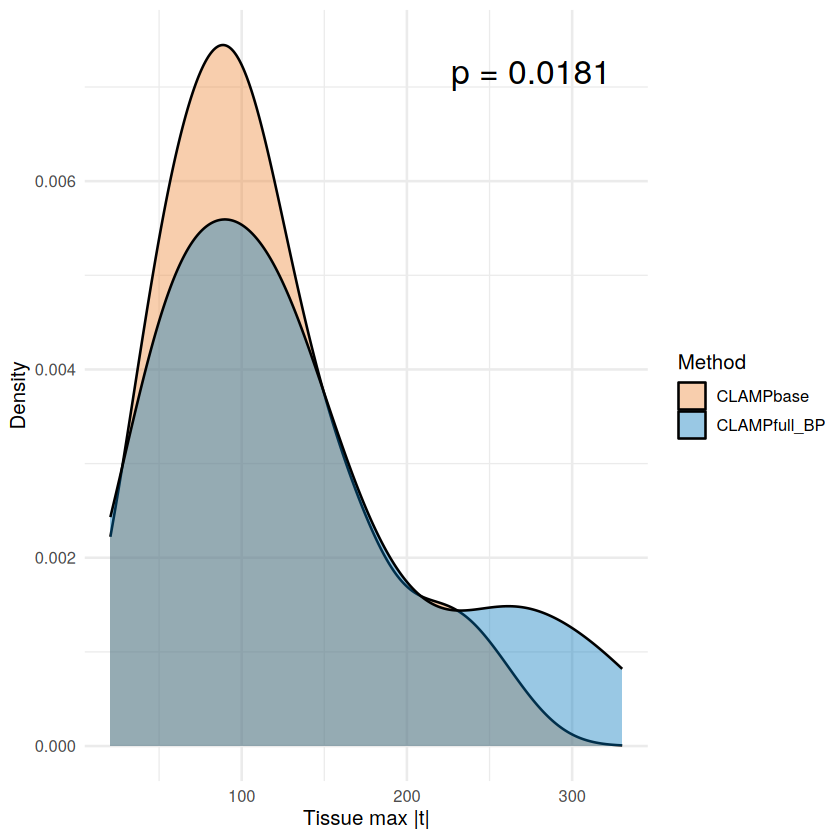

In [41]:
# Distributions max |t| + paired t-test (show only p-value) + colors from config.yaml

pt <- t.test(res_join$abs_t_full, res_join$abs_t_base, paired = TRUE)

res_long <- res_join %>%
  select(SMTS, abs_t_base, abs_t_full) %>%
  pivot_longer(c(abs_t_base, abs_t_full),
               names_to = "method", values_to = "abs_t") %>%
  mutate(method = recode(method,
                         abs_t_base = "CLAMPbase",
                         abs_t_full = "CLAMPfull_BP"))

pal <- c(
  CLAMPbase    = MODEL_COLORS[["CLAMP_base"]],
  CLAMPfull_BP = MODEL_COLORS[["CLAMP_BP"]]
)

xmax <- max(res_long$abs_t, na.rm = TRUE)
ymax <- ggplot_build(
  ggplot(res_long, aes(x = abs_t, fill = method)) + geom_density()
)$data[[1]]$y |> max(na.rm = TRUE)

label_txt <- paste0("p = ", format.pval(pt$p.value, digits = 3, eps = 1e-16))

ggplot(res_long, aes(x = abs_t, fill = method)) +
  geom_density(alpha = 0.4, adjust = 1, color = "black") +
  scale_fill_manual(values = pal, name = "Method") +
  annotate(
    "text",
    x = xmax * 0.98,
    y = ymax * 0.98,
    label = label_txt,
    hjust = 1, vjust = 1,
    size = 7
  ) +
  labs(x = "Tissue max |t|", y = "Density") +
  theme_minimal(base_size = 12)
